Escreva uma função para calcular a média e o desvio padrão de uma série temporal e aplique-a aos PBSdados. Plote a série com a maior média e a série com o menor desvio padrão.

In [14]:
from pathlib import Path

data_path = Path("../../data")

print("Arquivos dentro de data:")
print(list(data_path.iterdir()))

Arquivos dentro de data:
[WindowsPath('../../data/AirPassengers.csv'), WindowsPath('../../data/algeria_exports.csv'), WindowsPath('../../data/algeria_exports_unparsed.csv'), WindowsPath('../../data/anscombe.csv'), WindowsPath('../../data/ansett.csv'), WindowsPath('../../data/ansett_unparsed.csv'), WindowsPath('../../data/austa.csv'), WindowsPath('../../data/aus_accomodation.csv'), WindowsPath('../../data/aus_airpassengers.csv'), WindowsPath('../../data/aus_arrivals.csv'), WindowsPath('../../data/aus_economy.csv'), WindowsPath('../../data/aus_economy_unparsed.csv'), WindowsPath('../../data/aus_livestock.csv'), WindowsPath('../../data/aus_production.csv'), WindowsPath('../../data/aus_production_formatted.csv'), WindowsPath('../../data/aus_retail.csv'), WindowsPath('../../data/aus_tourism.csv'), WindowsPath('../../data/bank_calls.csv'), WindowsPath('../../data/boston_marathon.csv'), WindowsPath('../../data/canadian_gas.csv'), WindowsPath('../../data/chinese_gdp.csv'), WindowsPath('../../d

                     mean           std
Unnamed: 0   33798.500000  1.951343e+04
Scripts      35096.171534  1.068033e+05
Cost        868677.623408  2.987325e+06
Série com maior média: Cost
Série com menor desvio padrão: Unnamed: 0


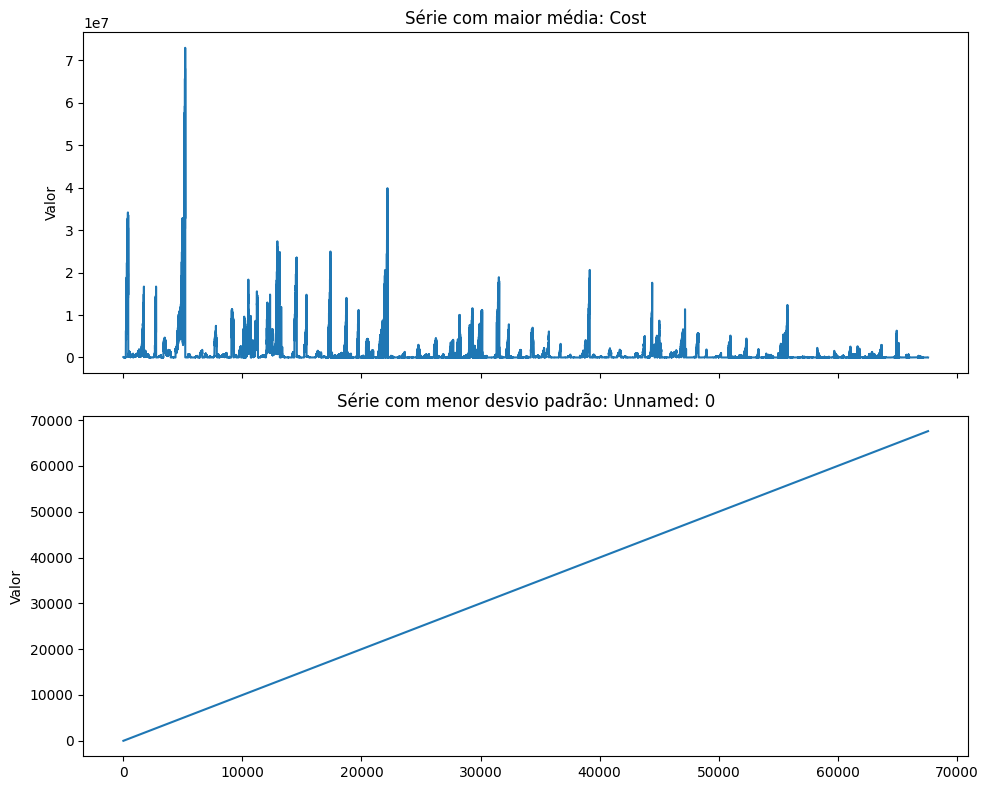

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

PBSdados = pd.read_csv("../../data/pbs.csv")

def calc_stats(data):
    if isinstance(data, pd.Series):
        return pd.DataFrame({
            "mean": [data.mean()],
            "std": [data.std()]
        }, index=[data.name or "PBSdados"])
    return pd.DataFrame({
        "mean": data.mean(numeric_only=True),
        "std": data.std(numeric_only=True)
    })

stats = calc_stats(PBSdados)
print(stats)

max_mean_col = stats["mean"].idxmax()
min_std_col = stats["std"].idxmin()

print(f"Série com maior média: {max_mean_col}")
print(f"Série com menor desvio padrão: {min_std_col}")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

if isinstance(PBSdados, pd.Series):
    PBSdados.plot(ax=axes[0], title=f"Série com maior média: {max_mean_col}")
    PBSdados.plot(ax=axes[1], title=f"Série com menor desvio padrão: {min_std_col}")
else:
    PBSdados[max_mean_col].plot(ax=axes[0], title=f"Série com maior média: {max_mean_col}")
    PBSdados[min_std_col].plot(ax=axes[1], title=f"Série com menor desvio padrão: {min_std_col}")

axes[0].set_ylabel("Valor")
axes[1].set_ylabel("Valor")
plt.tight_layout()
plt.show()

Utilize sns.pairplot()para analisar as relações entre as características baseadas em STL para a série de feriados nos tourismdados. Altere seasonal_peak_yeare seasonal_trough_yearpara fatores, conforme mostrado na Figura  4.3 . Qual é o trimestre de pico para feriados em cada estado?

In [ ]:
import seaborn as sns

tourism_files = list(data_path.glob("*tourism*.csv"))
if not tourism_files:
    tourism_files = list(data_path.glob("*tourismdados*.csv"))

if not tourism_files:
    raise FileNotFoundError(f"Nenhum arquivo de turismo encontrado em {data_path}")

tourismdados = pd.read_csv(tourism_files[0])

for col in ["seasonal_peak_year", "seasonal_trough_year"]:
    if col in tourismdados.columns:
        tourismdados[col] = tourismdados[col].astype("category")

print("Colunas em tourismdados:", tourismdados.columns.tolist())
print(tourismdados[["seasonal_peak_year", "seasonal_trough_year"]].dtypes)

state_col = next((c for c in tourismdados.columns if c.lower() == "state"), None)
if state_col is None:
    state_col = next((c for c in tourismdados.columns if "state" in c.lower()), None)

numeric_cols = [c for c in tourismdados.select_dtypes(include="number").columns if c != "Unnamed: 0"]

sns.pairplot(
    tourismdados,
    vars=numeric_cols,
    hue=state_col,
    corner=True,
    plot_kws={"alpha": 0.5}
)
plt.suptitle("Relações entre características baseadas em STL", y=1.02)
plt.show()

if state_col and "seasonal_peak_year" in tourismdados.columns:
    peak_by_state = (
        tourismdados.groupby(state_col)["seasonal_peak_year"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
        .rename("peak_quarter")
    )
    print("Trimestre de pico por estado:")
    print(peak_by_state)
else:
    print("Não foi possível determinar o trimestre de pico por estado sem as colunas necessárias.")

Colunas em tourismdados: ['ds', 'Region', 'State', 'Purpose', 'y']


KeyError: "None of [Index(['seasonal_peak_year', 'seasonal_trough_year'], dtype='object')] are in the [columns]"